In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from CoupledModel import CoupledModel

In [2]:


AMOC_load = {
    **torch.load('amoc_model.pth', weights_only=False),
    'scaler': 'scalers_AMOC.pkl'
}
SFWF_load = {
    **torch.load('SFWF_model.pth', weights_only=False),
    'scaler': 'scalers_SFWF.pkl'
}
PD_200m_load = {
    **torch.load('PD_200m_model.pth', weights_only=False),
    'scaler': 'scalers_PD_200m.pkl'
}

model = CoupledModel(AMOC_load, SFWF_load, PD_200m_load)

X = pd.read_csv('../data/CESMDataset_Try.csv')
device = 'cpu'
start_idx = 6000
lag = 50

AMOC_features = ['SFWF', 'PD_200m']
SFWF_features = ['AMOC', 'PD_200m']
PD_200m_features = ['SFWF', 'AMOC']

steps = 1000

AMOC, SFWF, PD_200m = model.predict(device, X, start_idx, lag, AMOC_features, SFWF_features, PD_200m_features, steps)



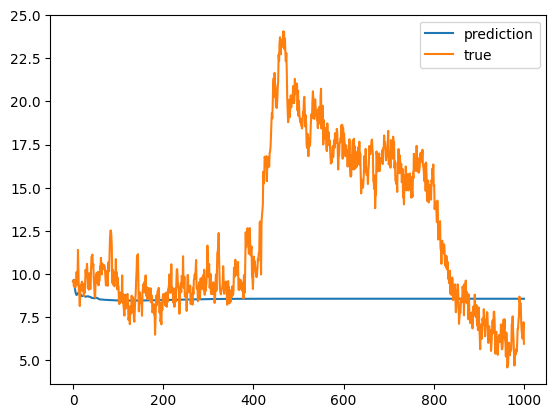

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

x = np.arange(steps+1)

ax.plot(x, AMOC, label = 'prediction')
ax.plot(x, X['AMOC'][start_idx:start_idx+steps+1], label = 'true')
ax.legend()